
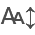

In [72]:
import pandas as pd
import os
import numpy as np
from copy import deepcopy

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import make_scorer, precision_score, f1_score, fbeta_score
from sklearn.model_selection import PredefinedSplit


from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

In [3]:
processed_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')
figures_path = os.path.join(os.getcwd(), '..', 'data', 'visualizations')

In [4]:
df = pd.read_csv(os.path.join(processed_data_input_path, 'initial_features_selected.csv'))

df = df.set_index('Unnamed: 0')
df.index.name = None
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [ ]:


benchmark_cols = [
    'season',
    'gameweek',
    'team',
    'opponent',
    'goals_scored',
    'goals_conceded',
    'prob_unexpected_result',
    'elo_unexpected_result',
    'win_probability',
    'draw_probability',
    'not_loss_probability',
    'win_odds',
    'draw_odds',
    'loss_odds'
]
df_benchmark = df[benchmark_cols].copy()
benchmark_cols.remove('prob_unexpected_result')
df = df.drop(columns=benchmark_cols)

df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


**Feature Importances**

Podział na zbiory uczący i treningowy

In [6]:
X1 = df.iloc[:, :-1]  
y1 = df.iloc[:, -1]

# Podział chronologiczny (80/20)
train_size = int(0.8 * len(X1))
X1_train, X1_test = X1.iloc[:train_size], X1.iloc[train_size:]
y1_train, y1_test = y1.iloc[:train_size], y1.iloc[train_size:]

X1_test

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Trenowanie modelu XGBoost

In [7]:
model1 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model1.fit(X1_train, y1_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Wyznaczenie ważności cech

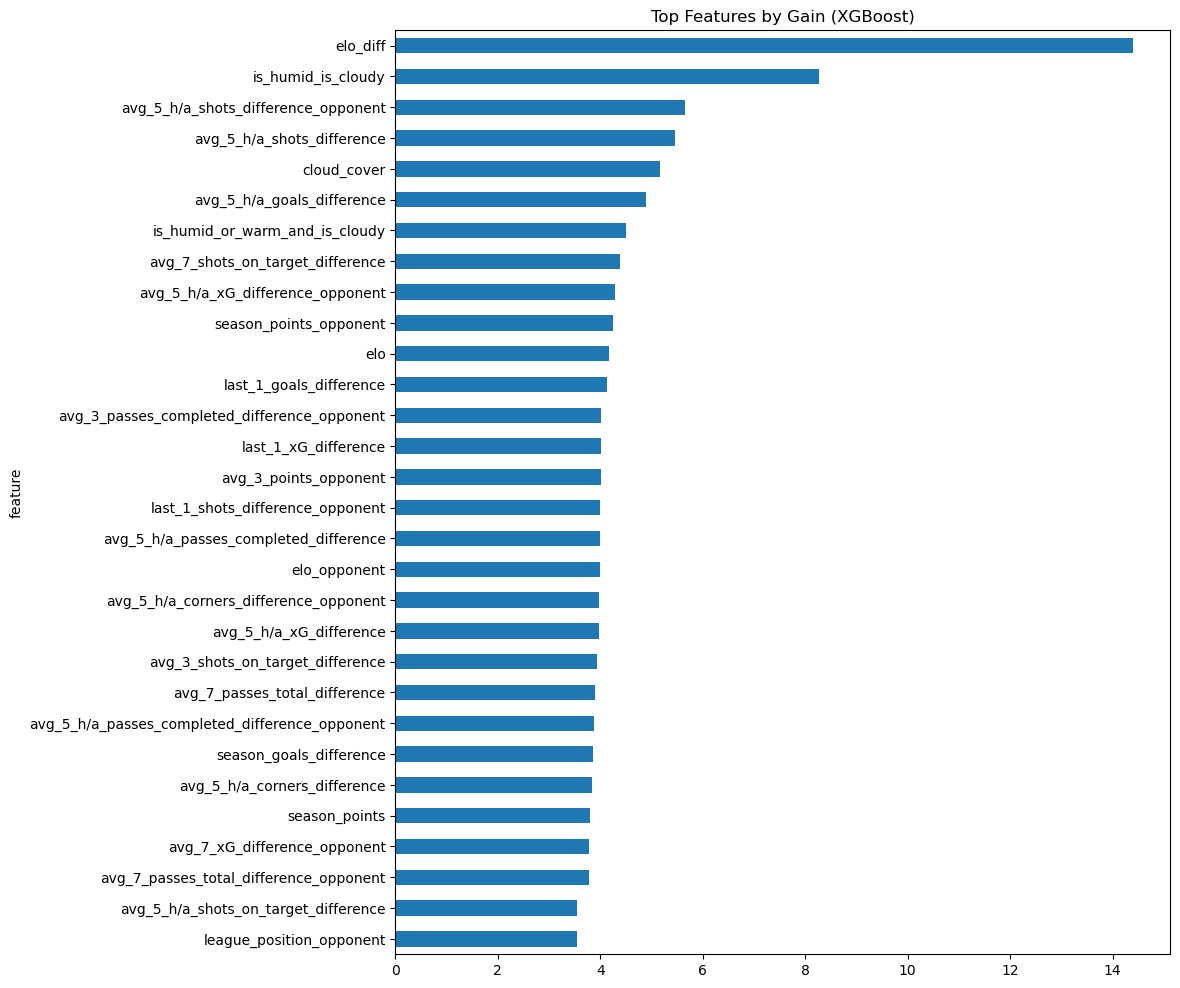

In [12]:
score_gain = pd.DataFrame(
    data={'feature': list(model1.get_booster().get_score(importance_type='gain').keys()),
          'gain': list(model1.get_booster().get_score(importance_type='gain').values())
          }
    )
score_weight = pd.DataFrame(
    data={'feature': list(model1.get_booster().get_score(importance_type='weight').keys()),
        'weight': list(model1.get_booster().get_score(importance_type='weight').values())
        }
    )
feature_importances = pd.DataFrame(data={'feature':X1.columns})
feature_importances = pd.merge(feature_importances, score_gain, on='feature', how='left')
feature_importances = pd.merge(feature_importances, score_weight, on='feature', how='left')

feature_importances = feature_importances.fillna(0)
feature_importances = feature_importances.sort_values(by='gain', ascending=False)
# Uporządkowanie i wykres
# importance_df = importance_df.sort_values(by='importance_gain', ascending=False)

# # Wykres
top_n = 30
feature_importances.head(top_n).plot(
    kind='barh',
    x='feature',
    y='gain',
    figsize=(10, 12),
    title='Top Features by Gain (XGBoost)',
    legend=False
)
plt.gca().invert_yaxis()
plt.show()

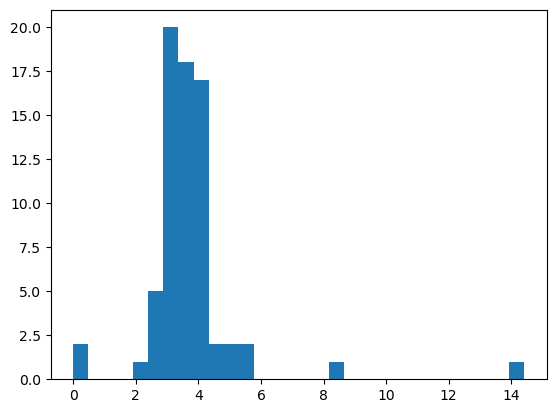

In [13]:
plt.hist(feature_importances['gain'], bins=30)
plt.show()

In [14]:
feature_importances[feature_importances['gain'] > 3]

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Dalsza redukcja cech - usuwane będą cechy mające niski gain i/lub wysoką korelację z innymi cechami

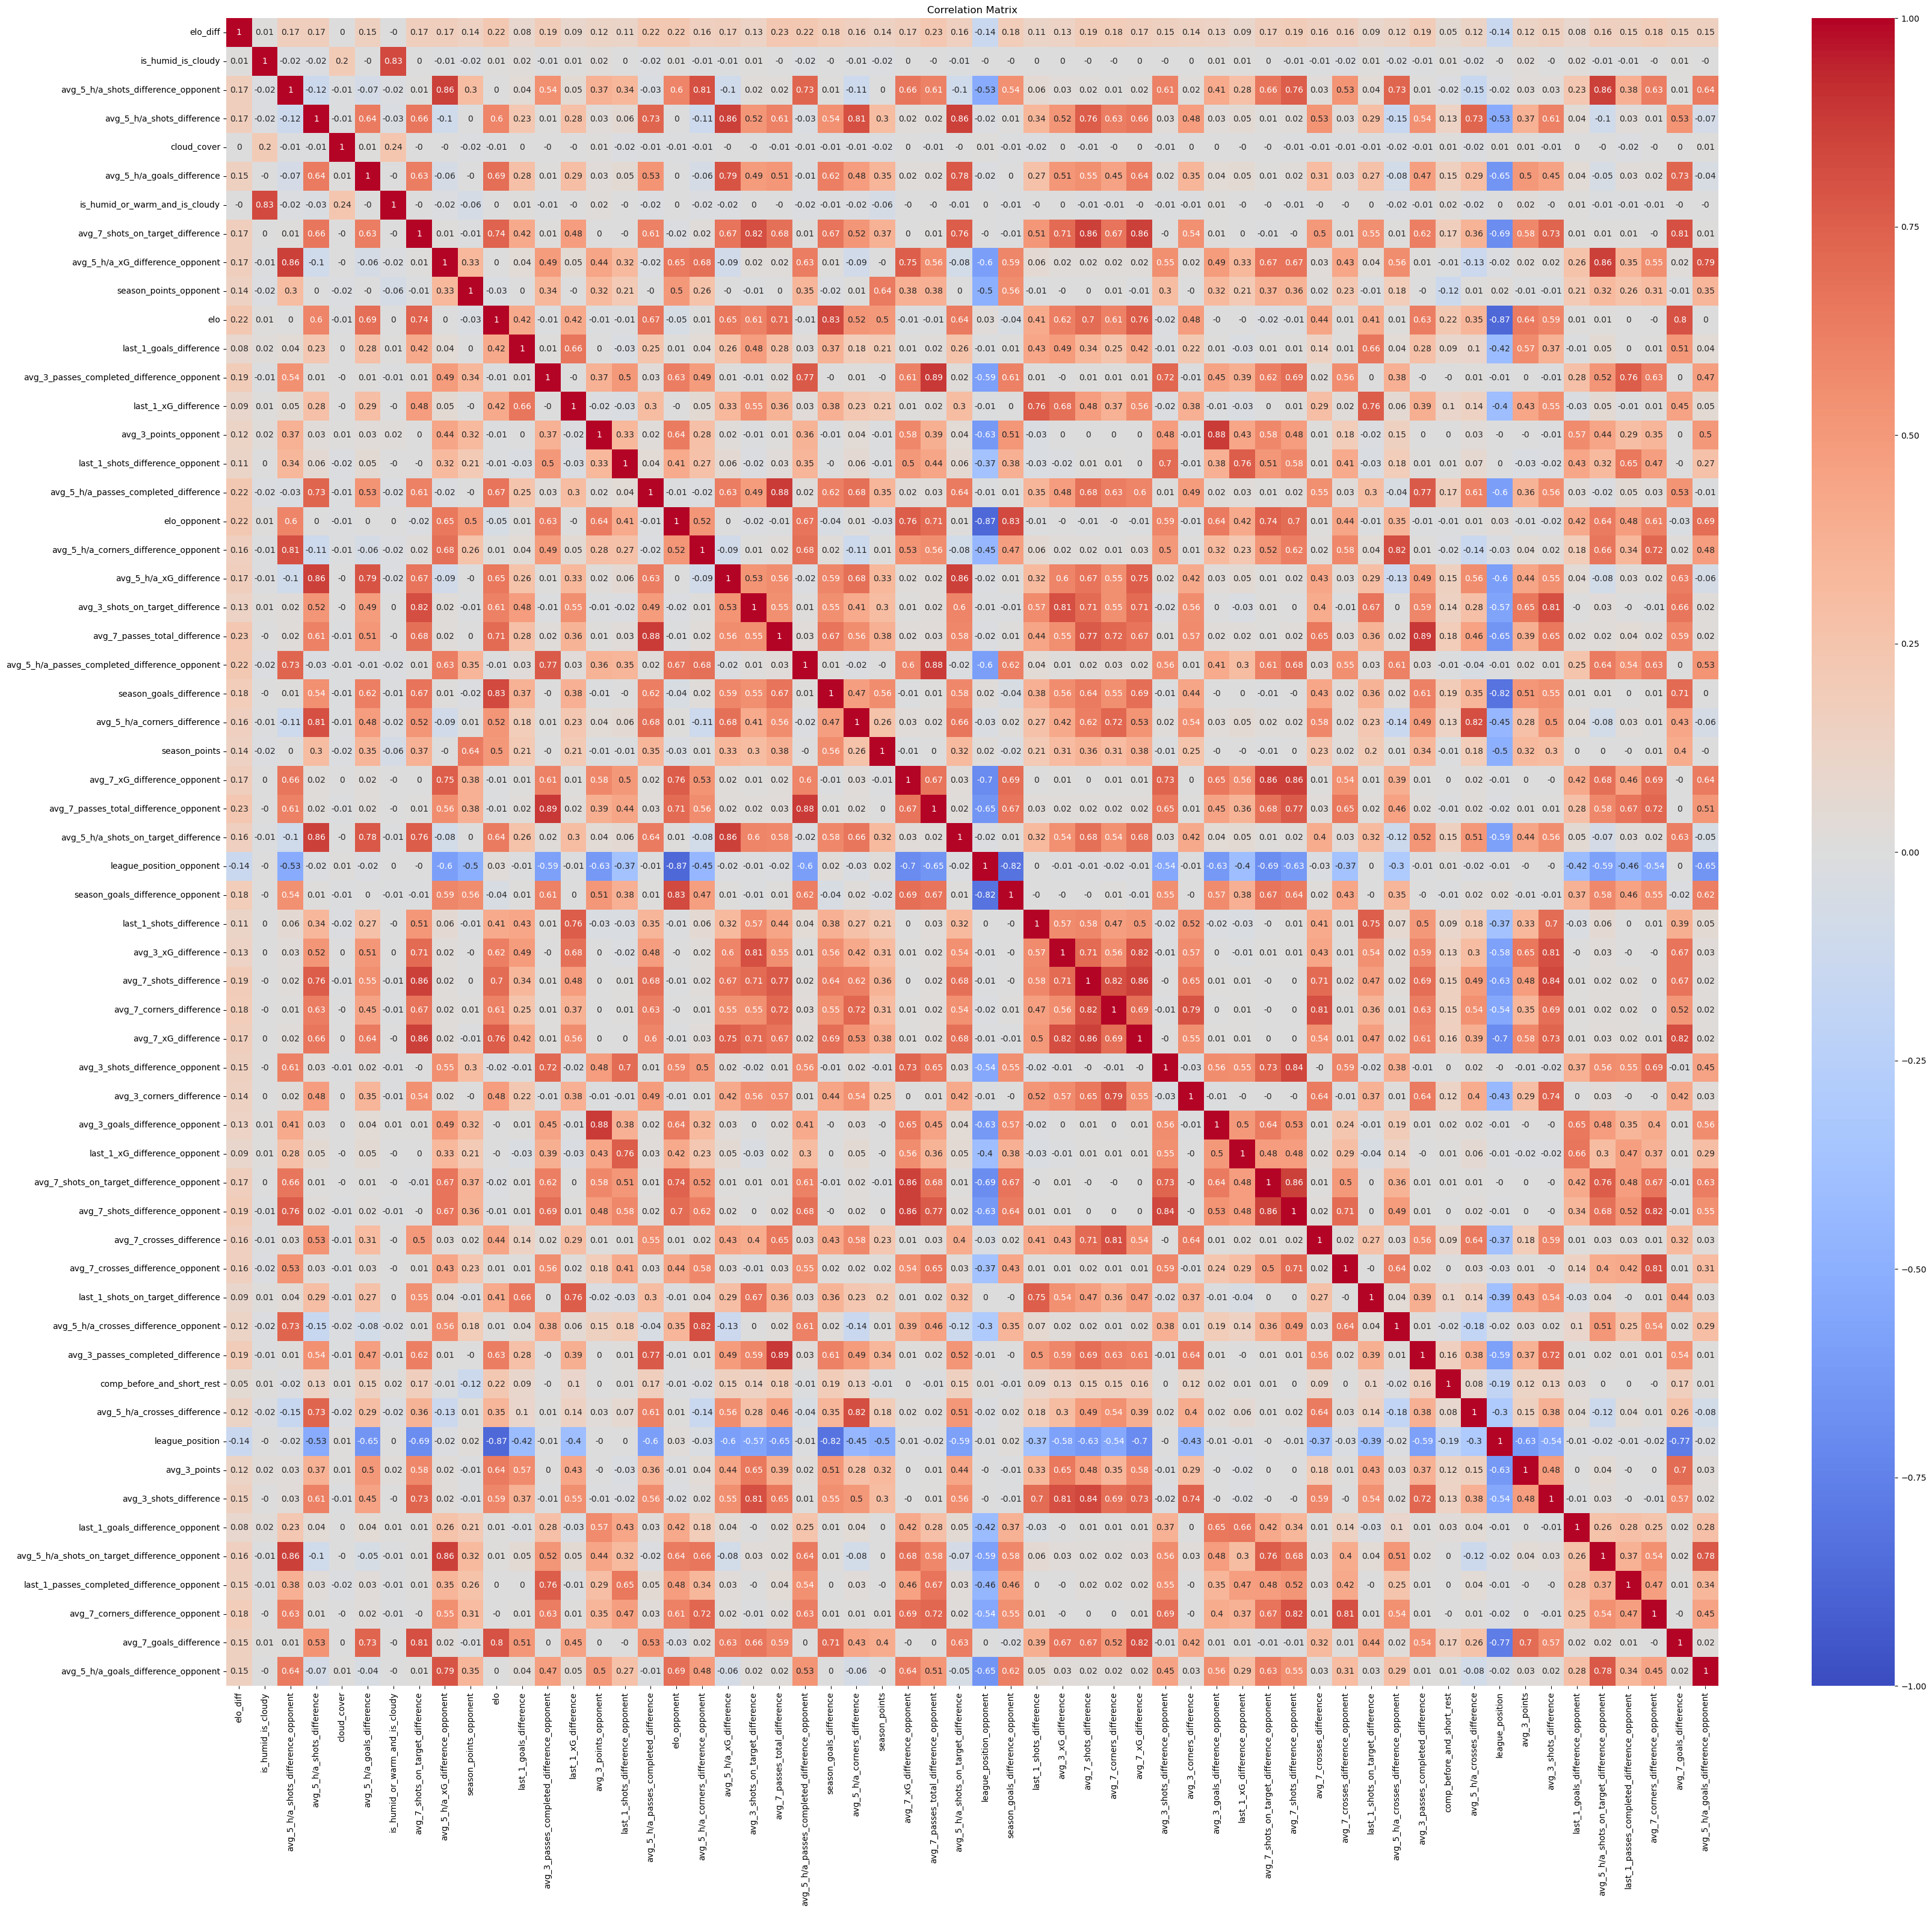

In [15]:
# Plot heatmap

corr = X1[feature_importances.loc[feature_importances['gain'] > 3, 'feature'].to_list()].corr().round(2)

plt.figure(figsize=(40, 36))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.savefig(os.path.join(figures_path, 'correlation_matrix_feature_imp.png'))
plt.show()

Ostateczna selekcja kolumn i podział na zbiory - treningowy, walidacyjny, testowy (70/15/15)

In [85]:
cols_to_drop = feature_importances.loc[feature_importances['gain'] < 3, 'feature'].to_list() 

cols = [col for col in X1.columns if col not in cols_to_drop] + ['prob_unexpected_result']

df_features = df[cols]

n = len(df_features)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

X_train = df_features.iloc[:train_end, :-1]
y_train = df_features.iloc[:train_end, -1]

X_val = df_features.iloc[train_end:val_end, :-1]
y_val = df_features.iloc[train_end:val_end, -1]

X_trainval = df_features.iloc[:val_end, :-1]
y_trainval = df_features.iloc[:val_end, -1]

X_test = df_features.iloc[val_end:, :-1]
y_test = df_features.iloc[val_end:, -1]   

# df_trainval = deepcopy(df_features.iloc[:val_end])
# df_trainval['match_id'] = df_trainval.index // 2


X_trainval


Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [80]:


param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [2, 4],  # liczba klas 0 / liczba klas 1
}

model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

f05_scorer = make_scorer(fbeta_score, beta=0.4, pos_label=1)
# precision_scorer = make_scorer(precision_score, pos_label=1)
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=200,
    scoring=f05_scorer,
    cv=TimeSeriesSplit(n_splits=5, test_size=500),
    verbose=2,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Najlepsze parametry:", search.best_params_)
print("Najlepszy wynik Precision:", search.best_score_)

# najlepsze parametry ale z data leakage
# {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 300, 'scale_pos_weight': 8, 'subsample': 0.8}

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Najlepsze parametry: {'subsample': 0.8, 'scale_pos_weight': 4, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Najlepszy wynik Precision: 0.2873074400977808


Dobór optymalnego progu klasyfikacji

ROC AUC: 0.765


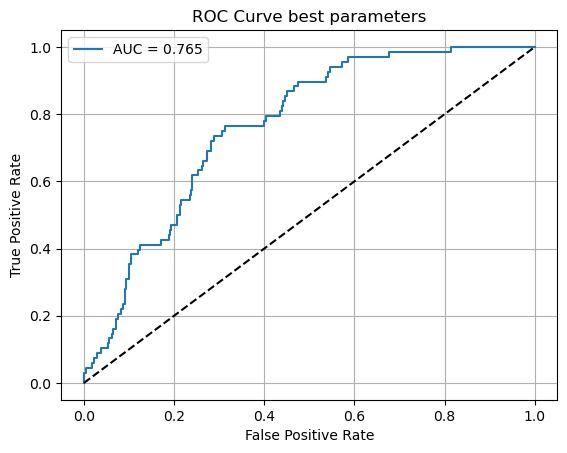


Threshold checked: 0.35



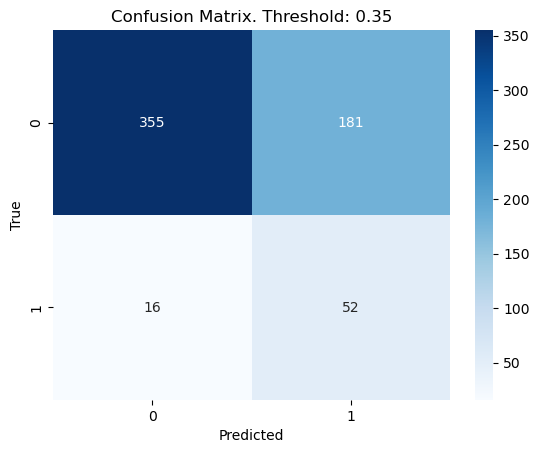

              precision    recall  f1-score   support

           0      0.957     0.662     0.783       536
           1      0.223     0.765     0.346        68

    accuracy                          0.674       604
   macro avg      0.590     0.714     0.564       604
weighted avg      0.874     0.674     0.734       604


Threshold checked: 0.4



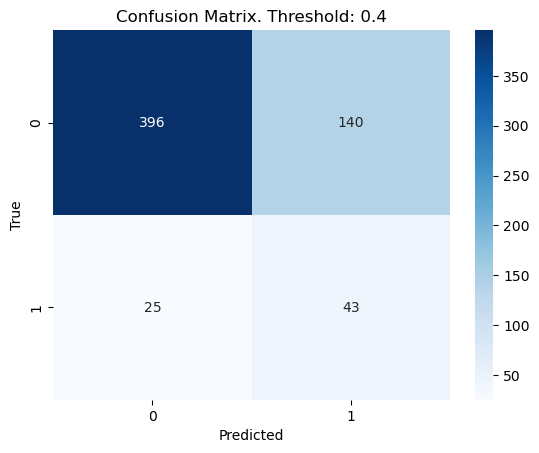

              precision    recall  f1-score   support

           0      0.941     0.739     0.828       536
           1      0.235     0.632     0.343        68

    accuracy                          0.727       604
   macro avg      0.588     0.686     0.585       604
weighted avg      0.861     0.727     0.773       604


Threshold checked: 0.45



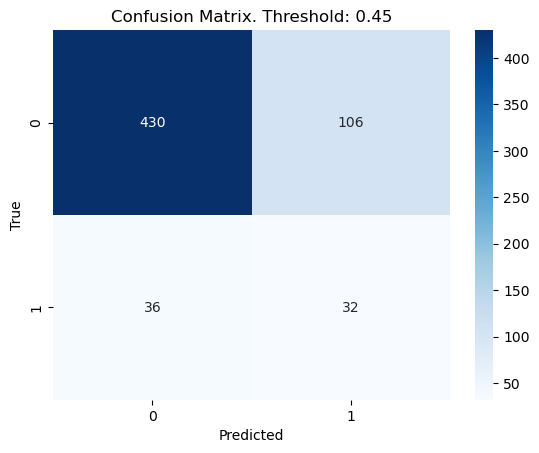

              precision    recall  f1-score   support

           0      0.923     0.802     0.858       536
           1      0.232     0.471     0.311        68

    accuracy                          0.765       604
   macro avg      0.577     0.636     0.584       604
weighted avg      0.845     0.765     0.797       604


Threshold checked: 0.47



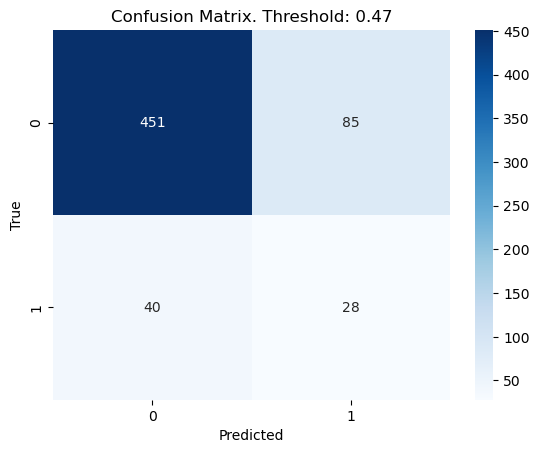

              precision    recall  f1-score   support

           0      0.919     0.841     0.878       536
           1      0.248     0.412     0.309        68

    accuracy                          0.793       604
   macro avg      0.583     0.627     0.594       604
weighted avg      0.843     0.793     0.814       604


Threshold checked: 0.48



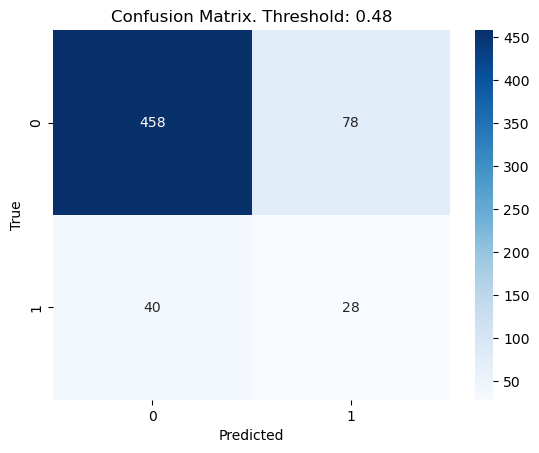

              precision    recall  f1-score   support

           0      0.920     0.854     0.886       536
           1      0.264     0.412     0.322        68

    accuracy                          0.805       604
   macro avg      0.592     0.633     0.604       604
weighted avg      0.846     0.805     0.822       604


Threshold checked: 0.5



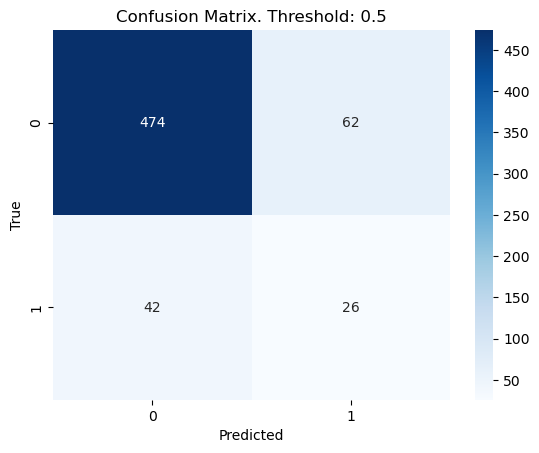

              precision    recall  f1-score   support

           0      0.919     0.884     0.901       536
           1      0.295     0.382     0.333        68

    accuracy                          0.828       604
   macro avg      0.607     0.633     0.617       604
weighted avg      0.848     0.828     0.837       604


Threshold checked: 0.55



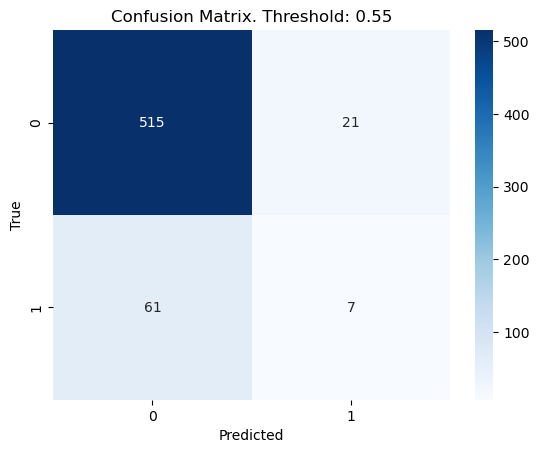

              precision    recall  f1-score   support

           0      0.894     0.961     0.926       536
           1      0.250     0.103     0.146        68

    accuracy                          0.864       604
   macro avg      0.572     0.532     0.536       604
weighted avg      0.822     0.864     0.838       604



In [ ]:

model2 = xgb.XGBClassifier(
    # current winner
    subsample=0.8,
    scale_pos_weight=4,
    n_estimators=300,
    min_child_weight=3,
    max_depth=4,
    learning_rate=0.01,
    colsample_bytree=1,
    

    # subsample=0.7,
    # scale_pos_weight=4,
    # n_estimators=400,
    # min_child_weight=3,
    # max_depth=4,
    # learning_rate=0.01,
    # colsample_bytree=1,
    random_state=42,
    eval_metric='logloss'
    # n_estimators=100,
    # max_depth=6,
    # learning_rate=0.1,
    # random_state=42,
    # eval_metric='logloss'
)




model2.fit(X_train, y_train)

y_prob2 = model2.predict_proba(X_val)[:, 1]



# 1. ROC AUC
auc_score = roc_auc_score(y_val, y_prob2)
print(f"ROC AUC: {auc_score:.3f}")

# 2. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob2)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve best parameters')
plt.legend()
plt.grid(True)
plt.show()

thresholds = [0.35, 0.4, 0.45, 0.47, 0.48, 0.5, 0.55]

for thr in thresholds:
    y_pred2 = (y_prob2 >= thr).astype(int)
    
    print(f'\nThreshold checked: {thr}\n')
    # 3. Confusion matrix
    cm = confusion_matrix(y_val, y_pred2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix. Threshold: {thr}')
    plt.show()

    # 4. Classification report
    print(classification_report(y_val, y_pred2, digits=3))




    


Testowanie zoptymalizowanego modelu na zbiorze testowym

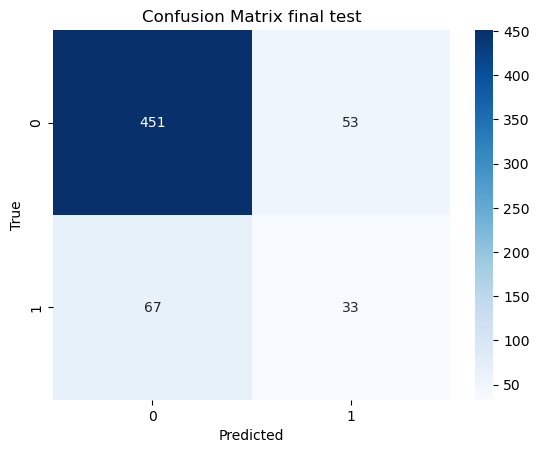

              precision    recall  f1-score   support

           0      0.871     0.895     0.883       504
           1      0.384     0.330     0.355       100

    accuracy                          0.801       604
   macro avg      0.627     0.612     0.619       604
weighted avg      0.790     0.801     0.795       604

ROC AUC: 0.729


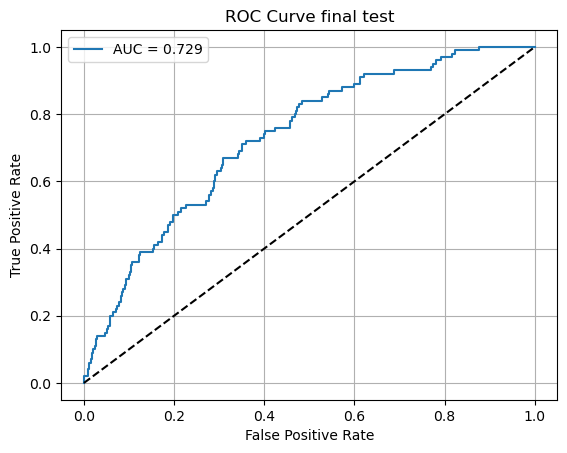

In [89]:
final_threshold = 0.5
model_final = xgb.XGBClassifier(
    # current winner
    subsample=0.8,
    scale_pos_weight=4,
    n_estimators=300,
    min_child_weight=3,
    max_depth=4,
    learning_rate=0.01,
    colsample_bytree=1,
    

    # subsample=0.7,
    # scale_pos_weight=4,
    # n_estimators=400,
    # min_child_weight=3,
    # max_depth=4,
    # learning_rate=0.01,
    # colsample_bytree=1,
    random_state=42,
    eval_metric='logloss'
    # n_estimators=100,
    # max_depth=6,
    # learning_rate=0.1,
    # random_state=42,
    # eval_metric='logloss'
)

model_final.fit(X_train, y_train)

y_prob_final = model_final.predict_proba(X_test)[:, 1]
y_pred_final = (y_prob_final >= final_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_test, y_pred_final, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_test, y_prob_final)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()
